In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import json

In [2]:
import sys, os
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[0]
sys.path.append(str(repo_path))

In [3]:
DATA_PATH = f"{repo_path}/data/"
GRAPH_PATH = f"{DATA_PATH}graph/"

### Reading the Graph

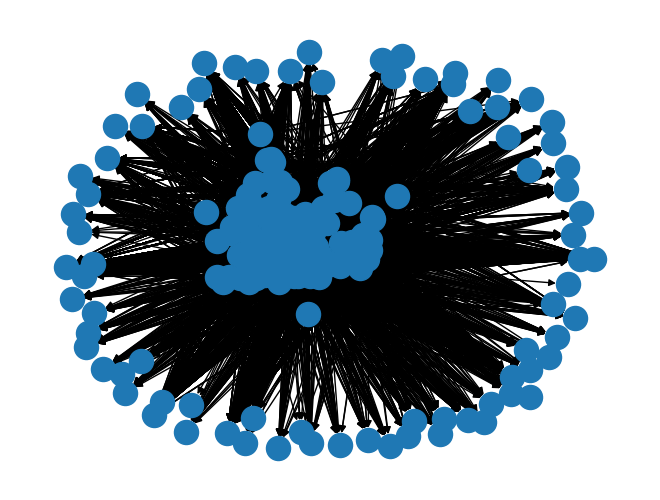

In [4]:
with open(f'{GRAPH_PATH}graph.json') as f:
    data = json.load(f)

H = nx.node_link_graph(data, edges="links")
nx.draw(H)

Node attributes:
For the MC1 knowledge graph, ‘id’, and ‘type’ are the mandatory attributes for all the nodes.
    • id – The unique identifier of the node and the label of the node
    • type – The type of node.
    • dob – The person’s date of birth
    • country – The country associated with the entity.

Metadata attributes:
Every single node and edge should have each of these fields.
    • _last_edited_by – The name of the user who last modified this node/edge
    • _last_edited_date – The last time this node/edge was modified
    • _date_added – The day on which this node/edge was first added to the graph
    • _raw_source – The news source from which the information was originally obtained
    • _algorithm – The method in which the information was obtained (for this mini-challenge, either automatically imported from pre-existing databases or manually updated by FishEye analysts)
    • _articleid – The natural language description of the extracted knowledge graph node/edges from news organizations, government reports, etc. 

### Structural Analysis

(215, 215)


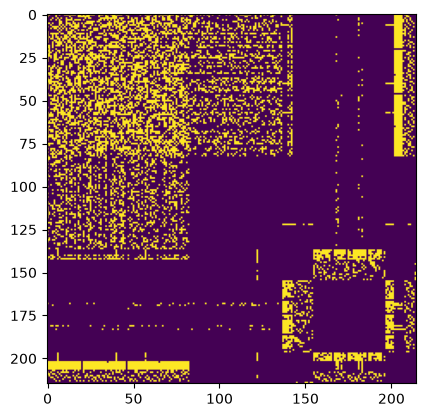

In [5]:
A = nx.adjacency_matrix(H).todense()
A[A>0] = 1
print(A.shape)
for i in range(215):
    for j in range(215):
        if A[i,j]==1:
            A[j,i]=1
plt.imshow(A)

In [6]:
V,U = np.linalg.eigh(A)
ep = U[:,:2]
ep.shape
eigen_position = {}
for i, nk in enumerate(H.nodes()):
    eigen_position[nk] = list(ep[i,:])

### In vs Out Degrees

In [7]:
in_degrees = dict(H.in_degree())
out_degrees = dict(H.out_degree())

In [8]:
def plot_degrees_hist(G,zero=True):
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())
    in_degree, in_counts = np.unique(list(in_degrees.values()), return_counts=True)
    out_degree,out_counts = np.unique(list(out_degrees.values()), return_counts=True)

    if not zero and in_degree[0]==0:
        in_degree = in_degree[1:]
        in_counts = in_counts[1:]
    if not zero and out_degree[0]==0:
        out_degree = out_degree[1:]
        out_counts = out_counts[1:]

    in_degree = [str(x) for x in in_degree]
    out_degree = [str(x) for x in out_degree]

    plt.figure(figsize=(12,10))
    plt.subplot(2, 1, 1)
    plt.bar(in_degree,in_counts)
    plt.tick_params(rotation=60,labelsize=8)
    plt.xlabel("In-Degree")
    plt.ylabel("Frequency")
    plt.title("In-Degree Distribution")

    # Out-degree histogram
    plt.subplot(2, 1, 2)
    plt.bar(out_degree,out_counts)
    plt.tick_params(rotation=60,labelsize=5)
    plt.xlabel("Out-Degree")
    plt.ylabel("Frequency")
    plt.title("Out-Degree Distribution")

    plt.suptitle("Degree Distribution of Directed Graph", fontsize=14)
    plt.tight_layout()
    plt.show()

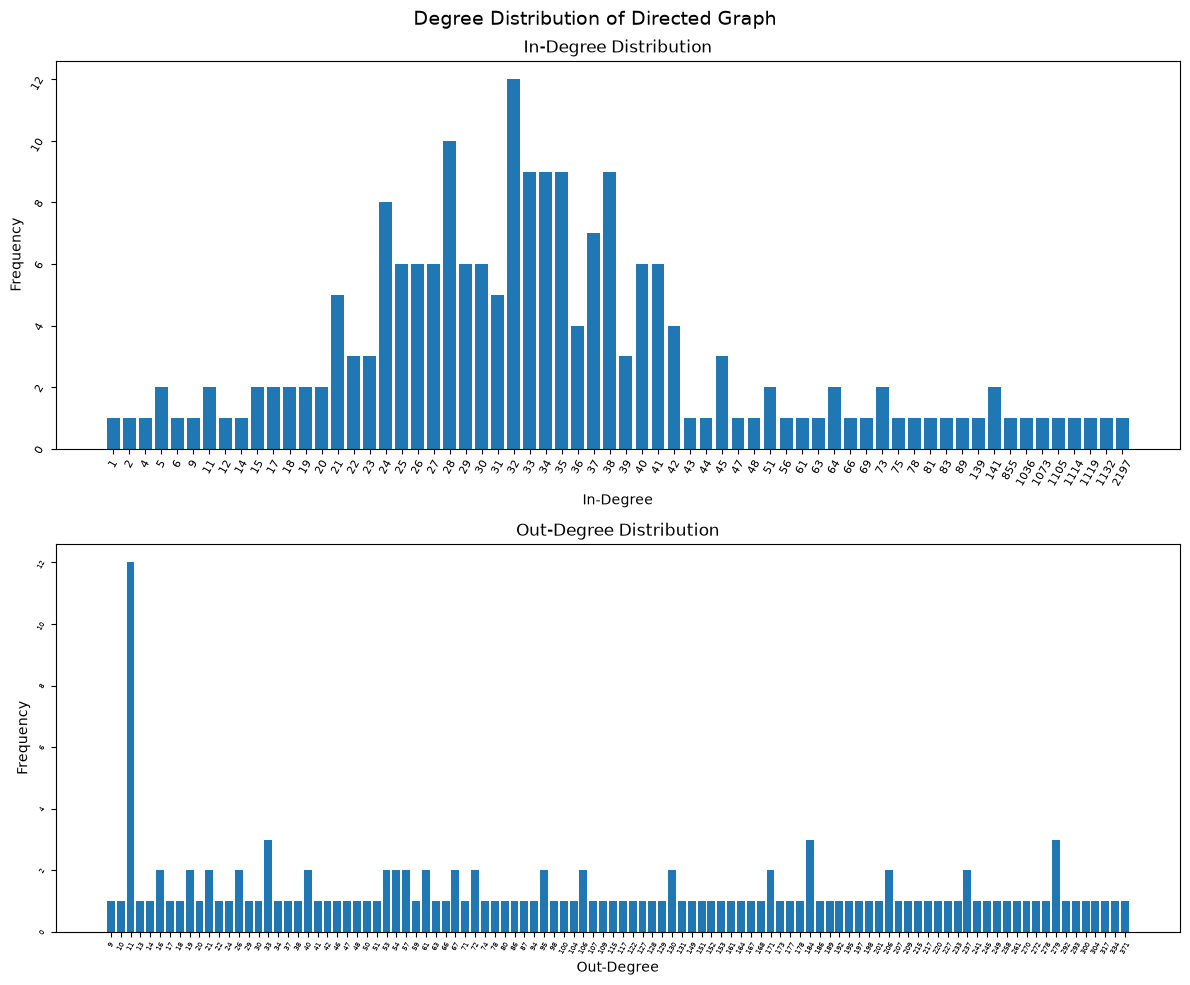

In [9]:
plot_degrees_hist(H,zero=False)

### Node Types

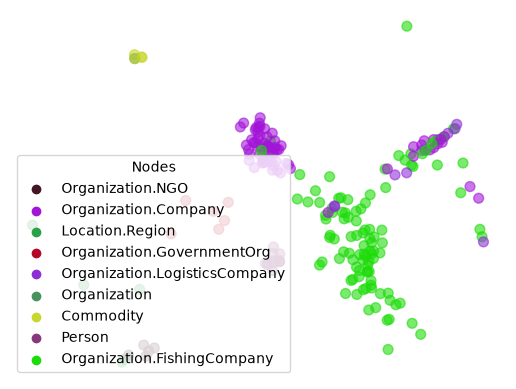

In [10]:
types_nodes = {'Entity.Organization.NGO':0, 'Entity.Organization.Company':1,
               'Entity.Location.Region':2, 'Entity.Organization.GovernmentOrg':3,
               'Entity.Organization.LogisticsCompany':4, 'Entity.Organization':5,
               'Entity.Commodity':6, 'Entity.Person':7, 'Entity.Organization.FishingCompany':8}

colors = np.random.rand(len(types_nodes), 3)
color_node = [colors[types_nodes[data['type']]] for k,data in H.nodes(data=True)]
handles = [plt.scatter([], [], color=c) for c in colors]
plt.legend(handles, [lb[7:]for lb in types_nodes.keys()], title='Nodes')

edges = list(H.edges())
draft_graph = H.copy()
draft_graph.remove_edges_from(edges)
nx.draw(draft_graph,pos=eigen_position,node_size=50,alpha=0.58,node_color=color_node)

### Edge Type Subgraphs

In [11]:
def separate_by_edge_type(G,type):
    """
    Separates a MultiDiGraph based on edge types.

    Args:
    G (networkx.MultiDiGraph): The input MultiDiGraph.
    type (str): The target edge type

    Returns:
    separate_graphs: a graph with just edges of the passed type
    """
    separate_graphs = G.copy()
    separate_graphs.remove_edges_from([(u,v,k,data) for u,v,k,data in G.edges(keys=True,data=True) if data['type']!=type])
    return separate_graphs

In [12]:
edges_types = ['Event.Aid', 'Event.Fishing', 'Event.Transaction', 'Event.Fishing.OverFishing',
               'Event.Fishing.SustainableFishing', 'Event.Convicted', 'Event.Applaud','Event.CertificateIssued',
               'Event.Criticize','Event.Owns.PartiallyOwns', 'Event.Communication.Conference',
               'Event.Invest', 'Event.CertificateIssued.Summons']
sub_graphs = {}

sub Graph of Event.Aid
1132 edges ( 6.97 %)


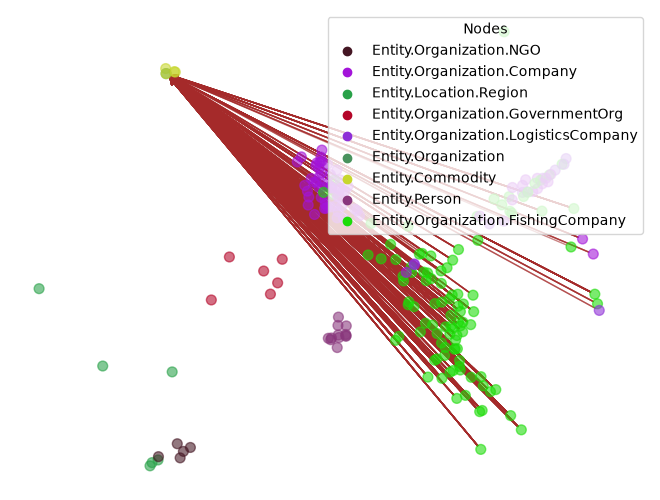

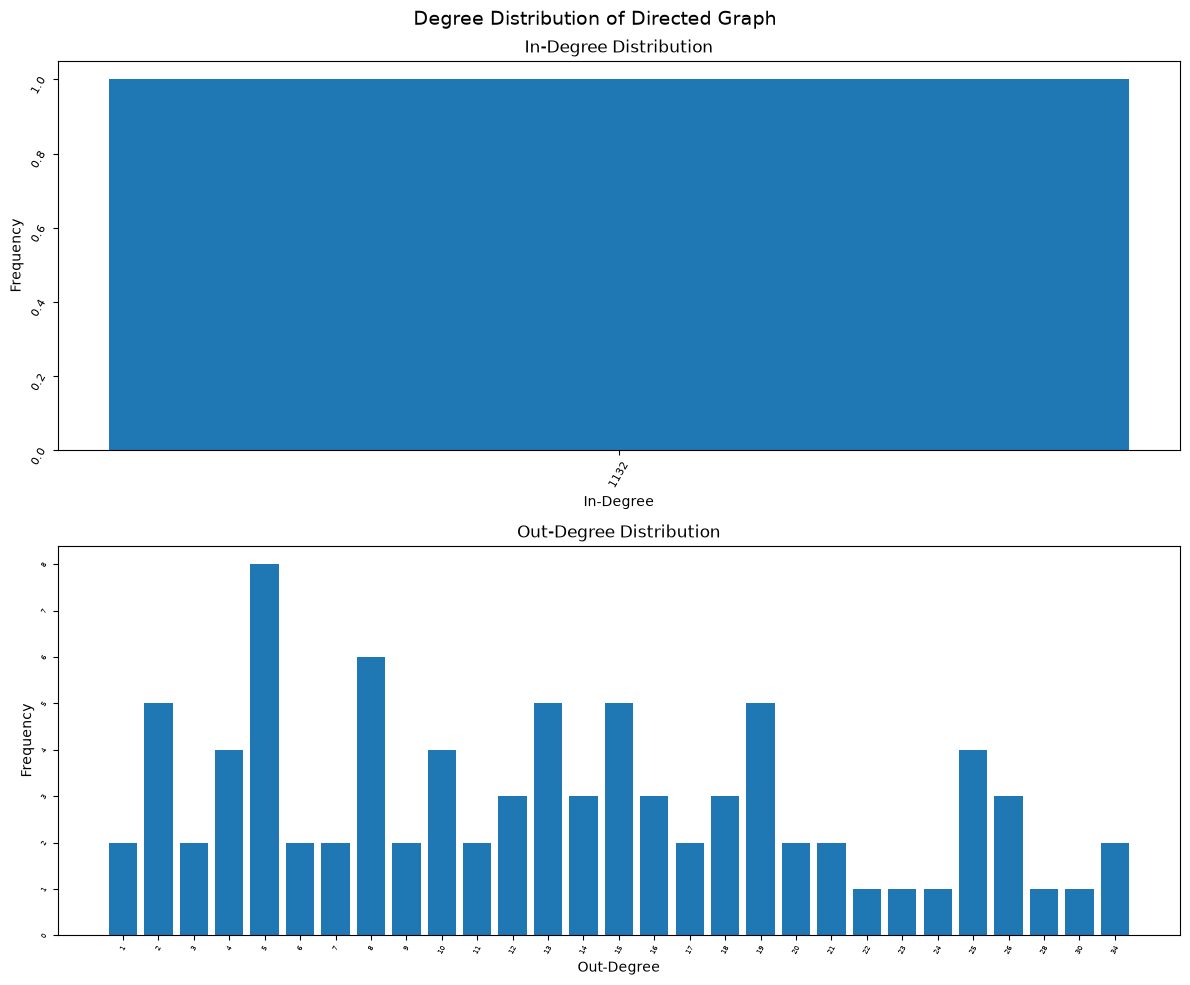

sub Graph of Event.Fishing
1482 edges ( 9.13 %)


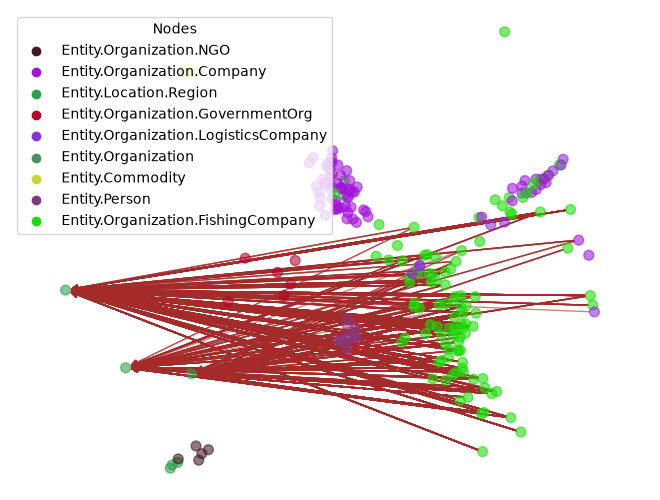

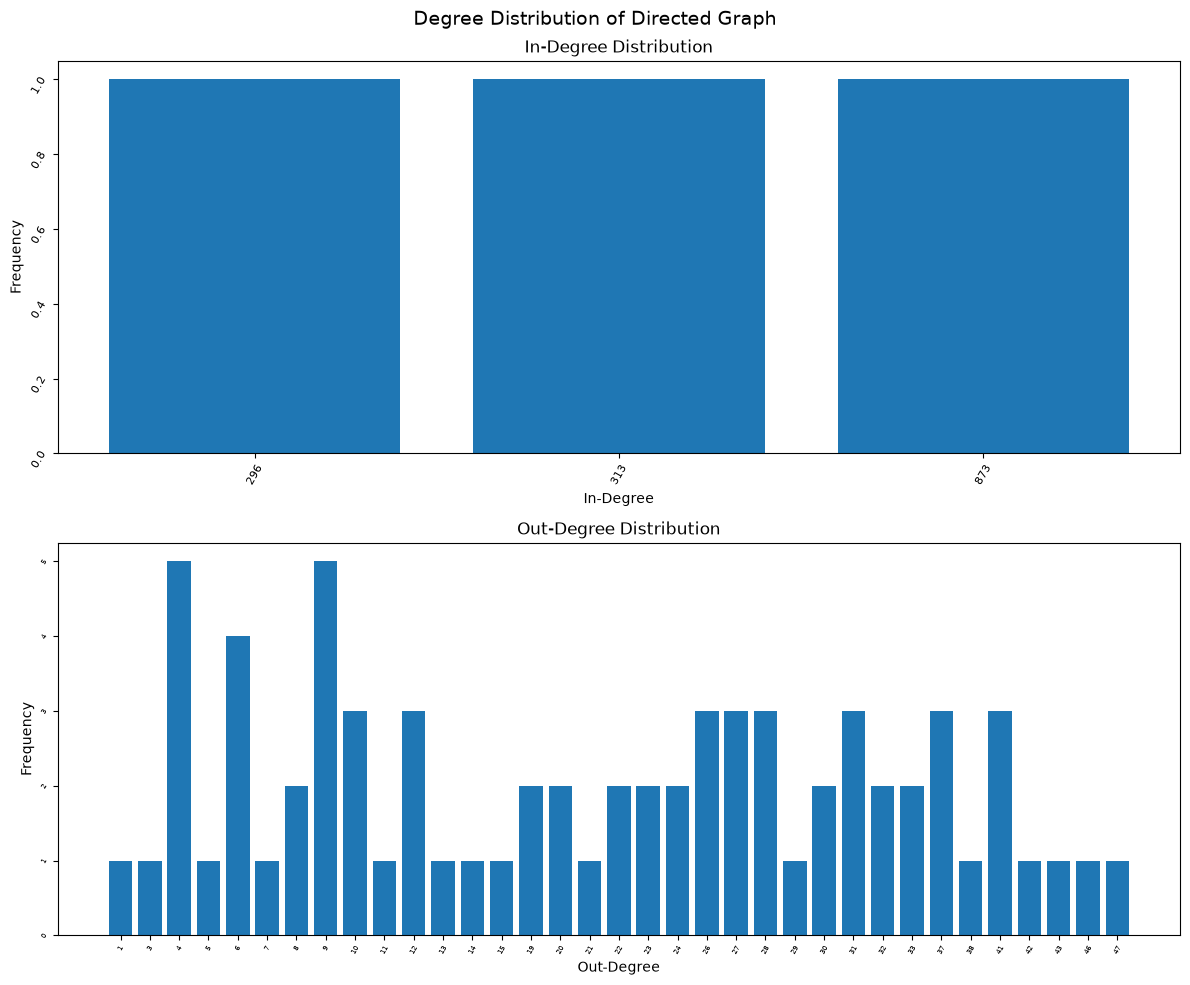

sub Graph of Event.Transaction
3254 edges ( 20.05 %)


/home/felipe/anaconda3/envs/fish/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


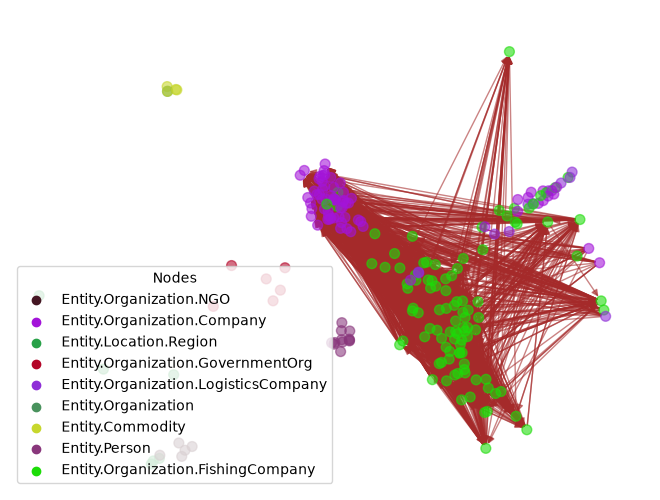

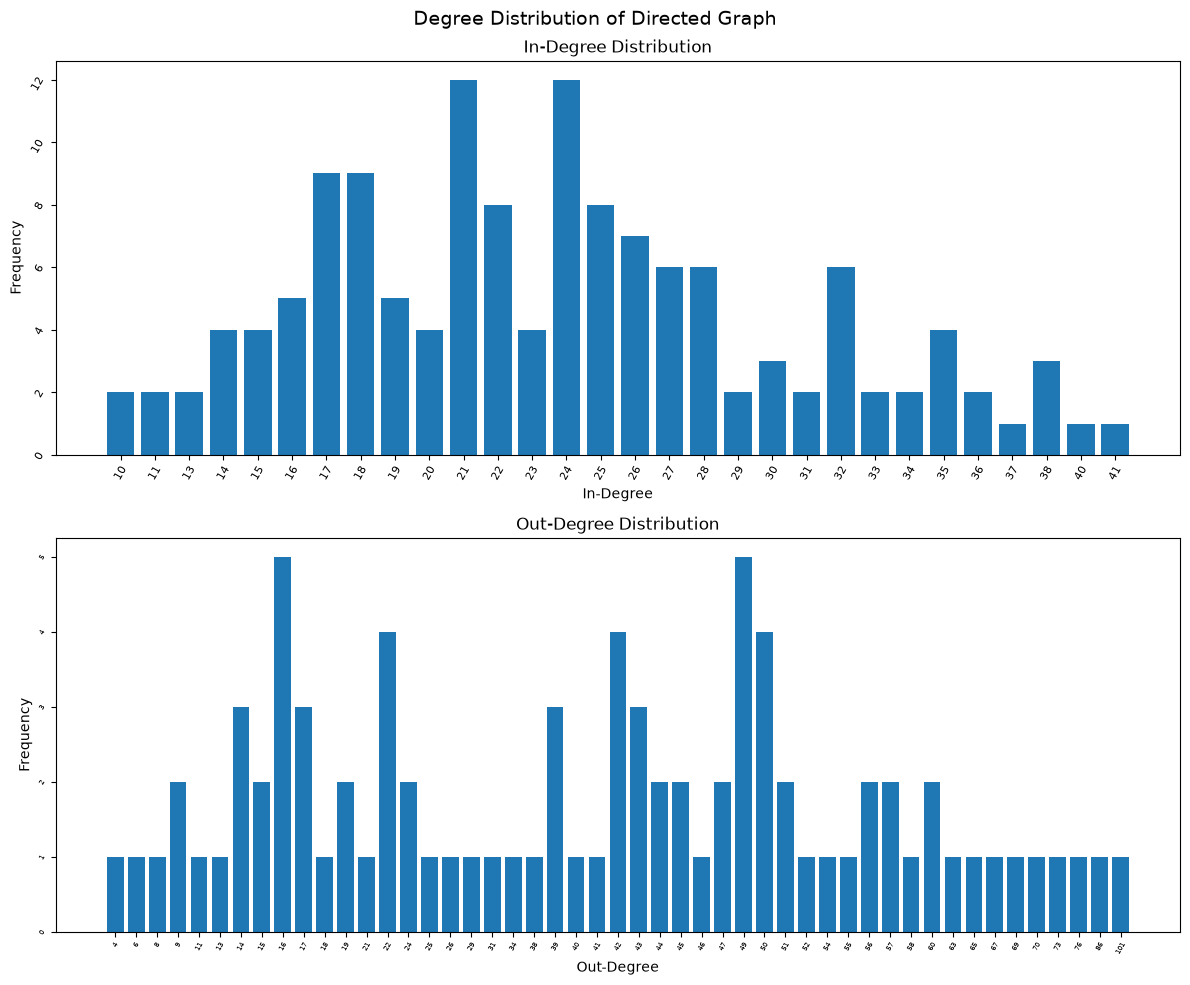

sub Graph of Event.Fishing.OverFishing
1658 edges ( 10.22 %)


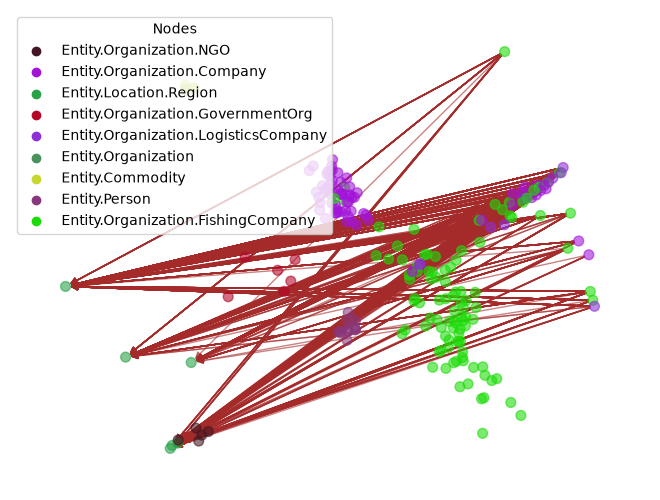

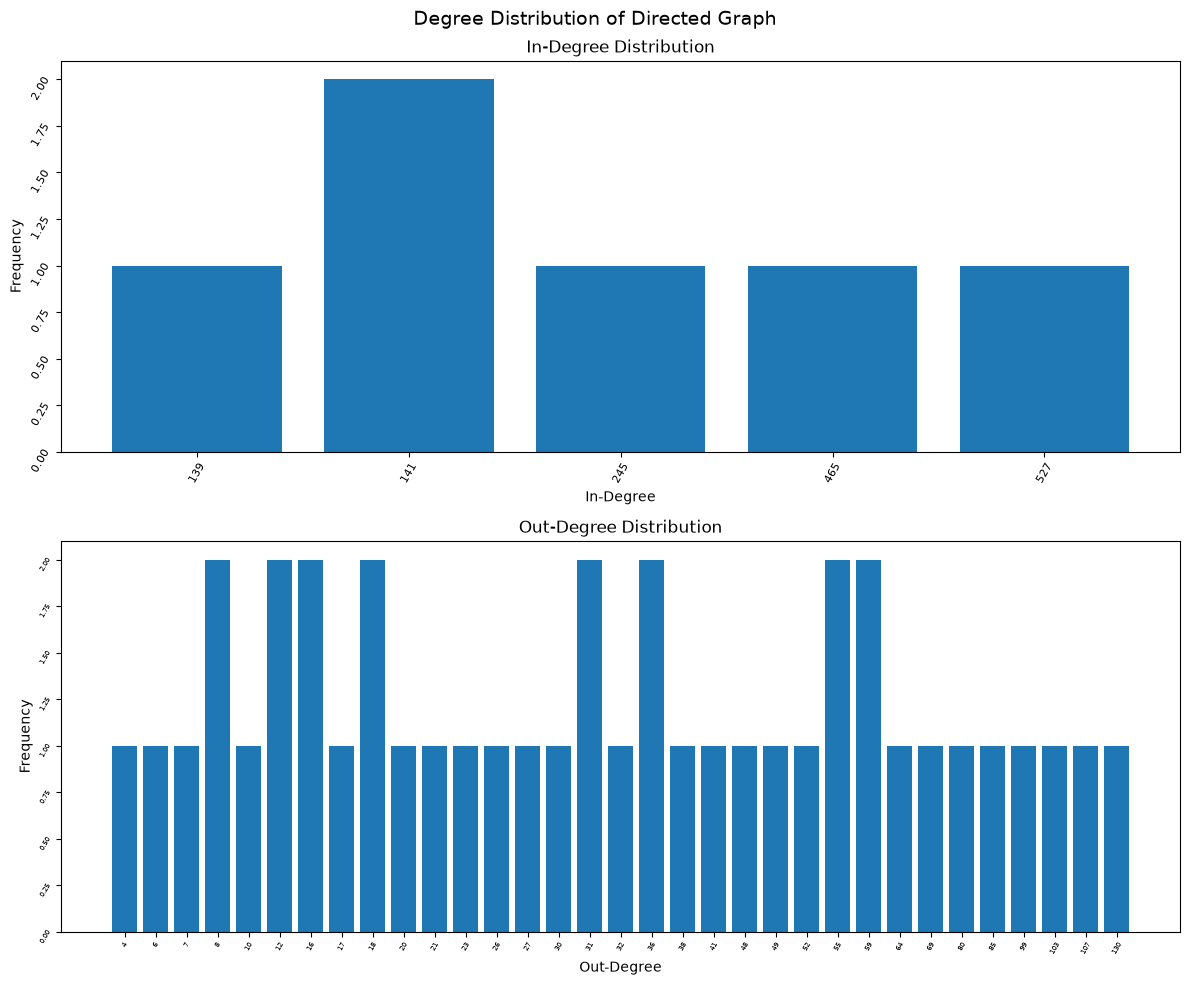

sub Graph of Event.Fishing.SustainableFishing
1406 edges ( 8.66 %)


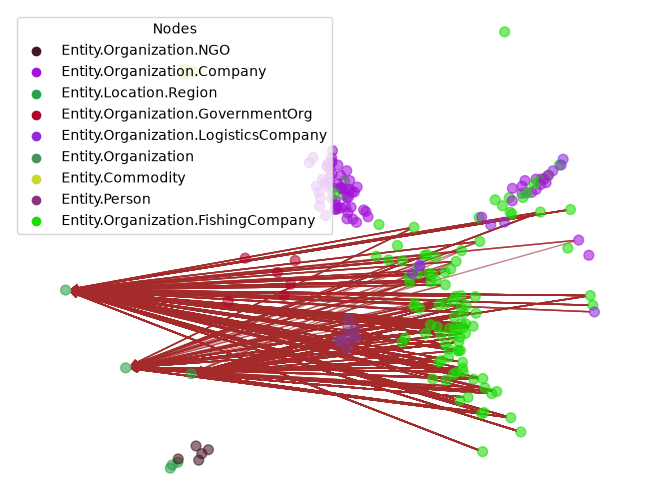

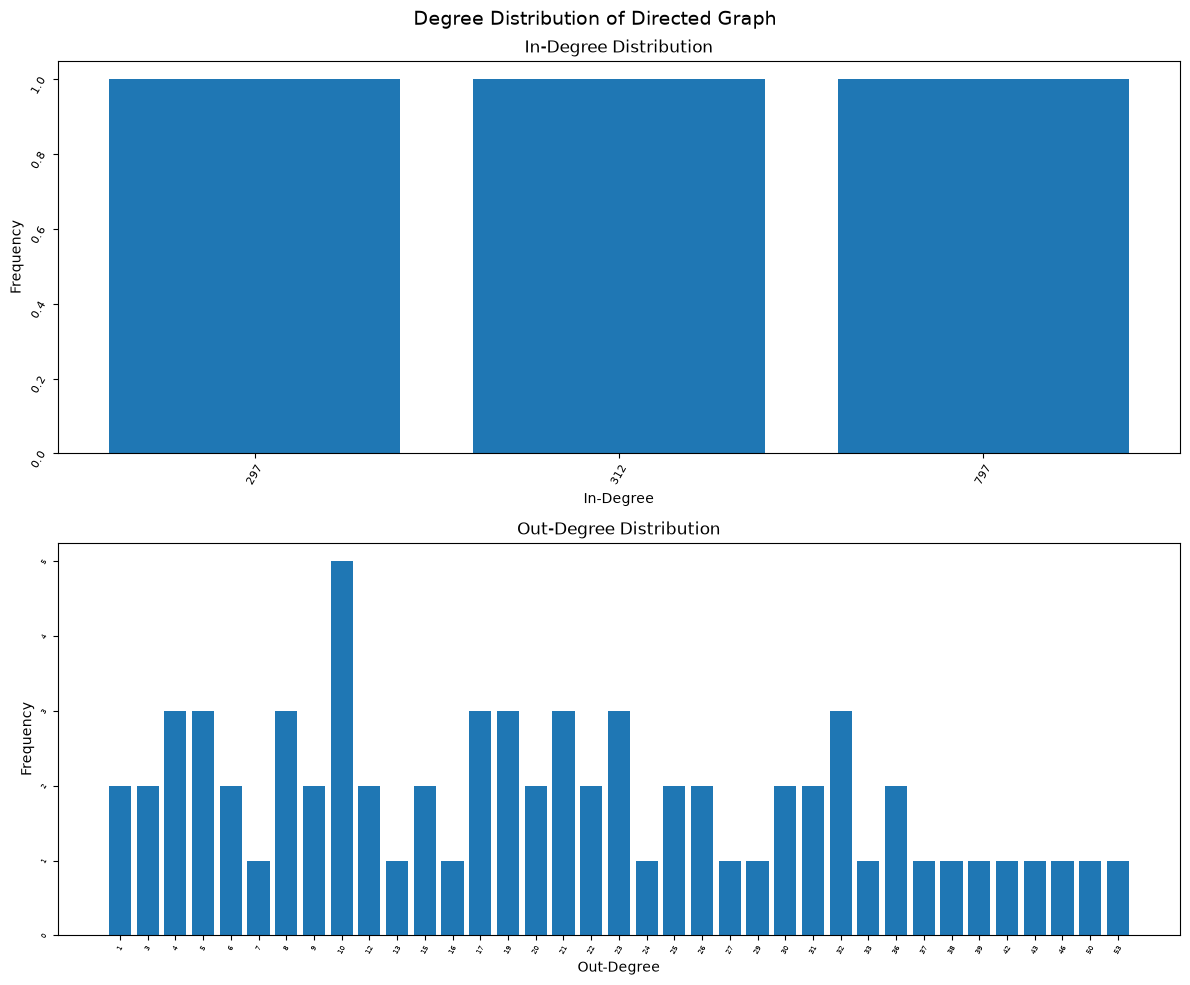

sub Graph of Event.Convicted
67 edges ( 0.41 %)


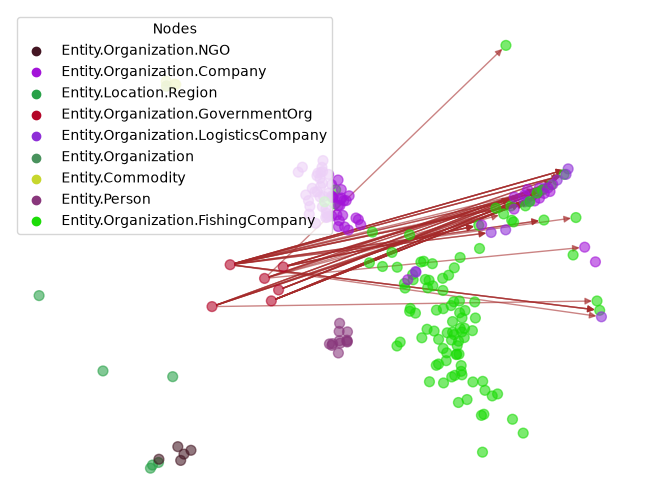

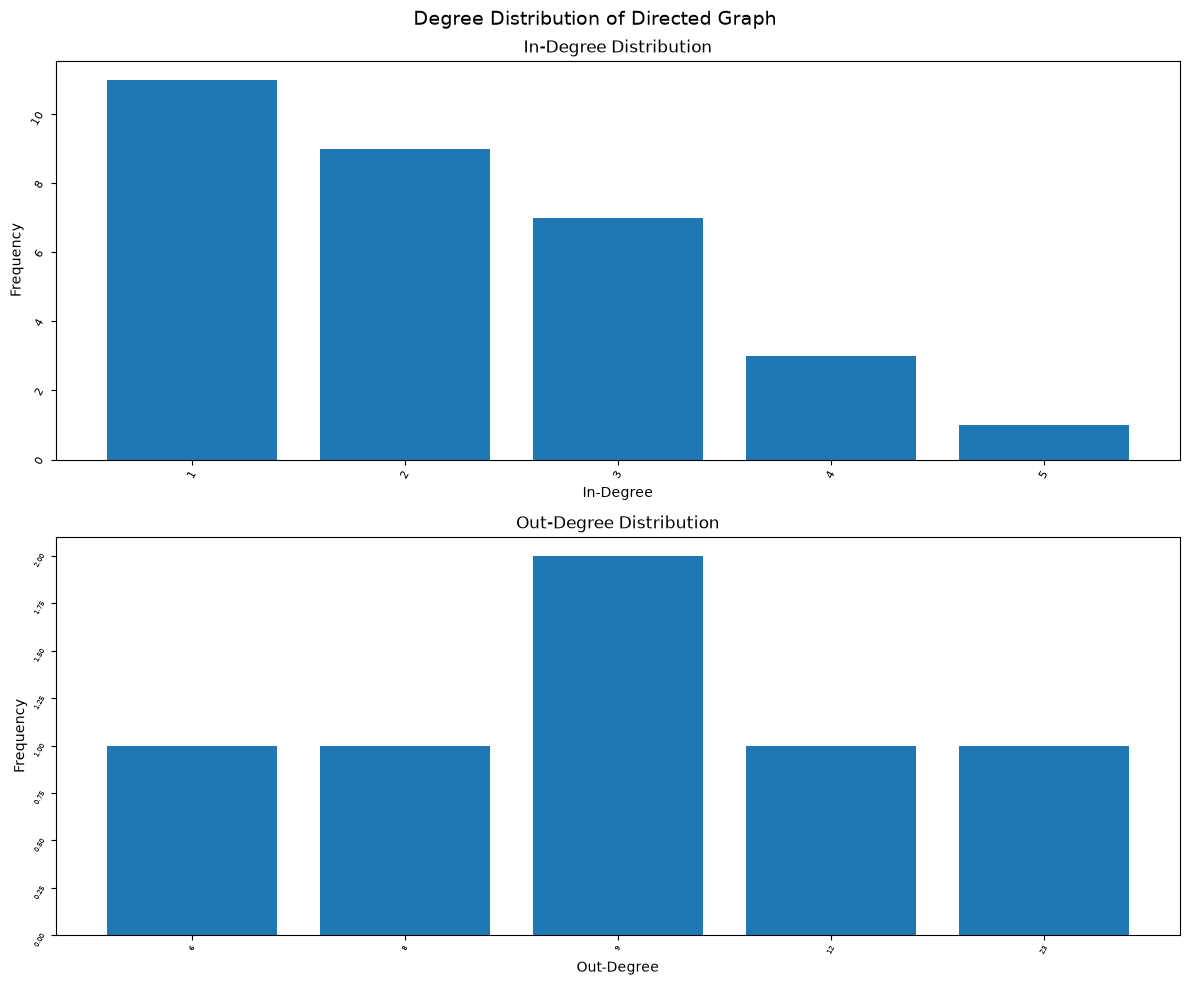

sub Graph of Event.Applaud
233 edges ( 1.44 %)


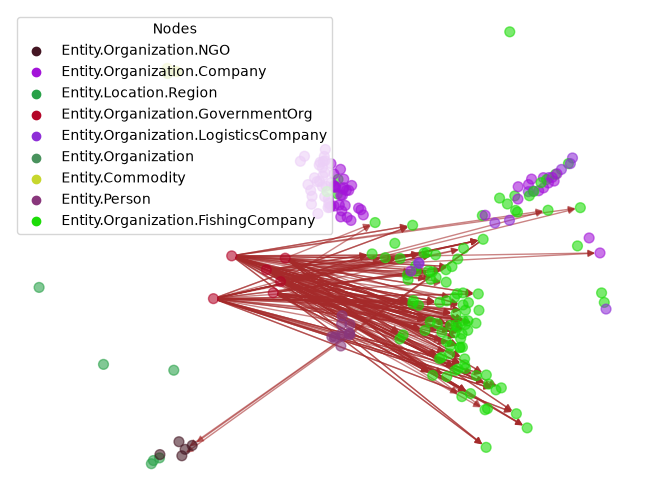

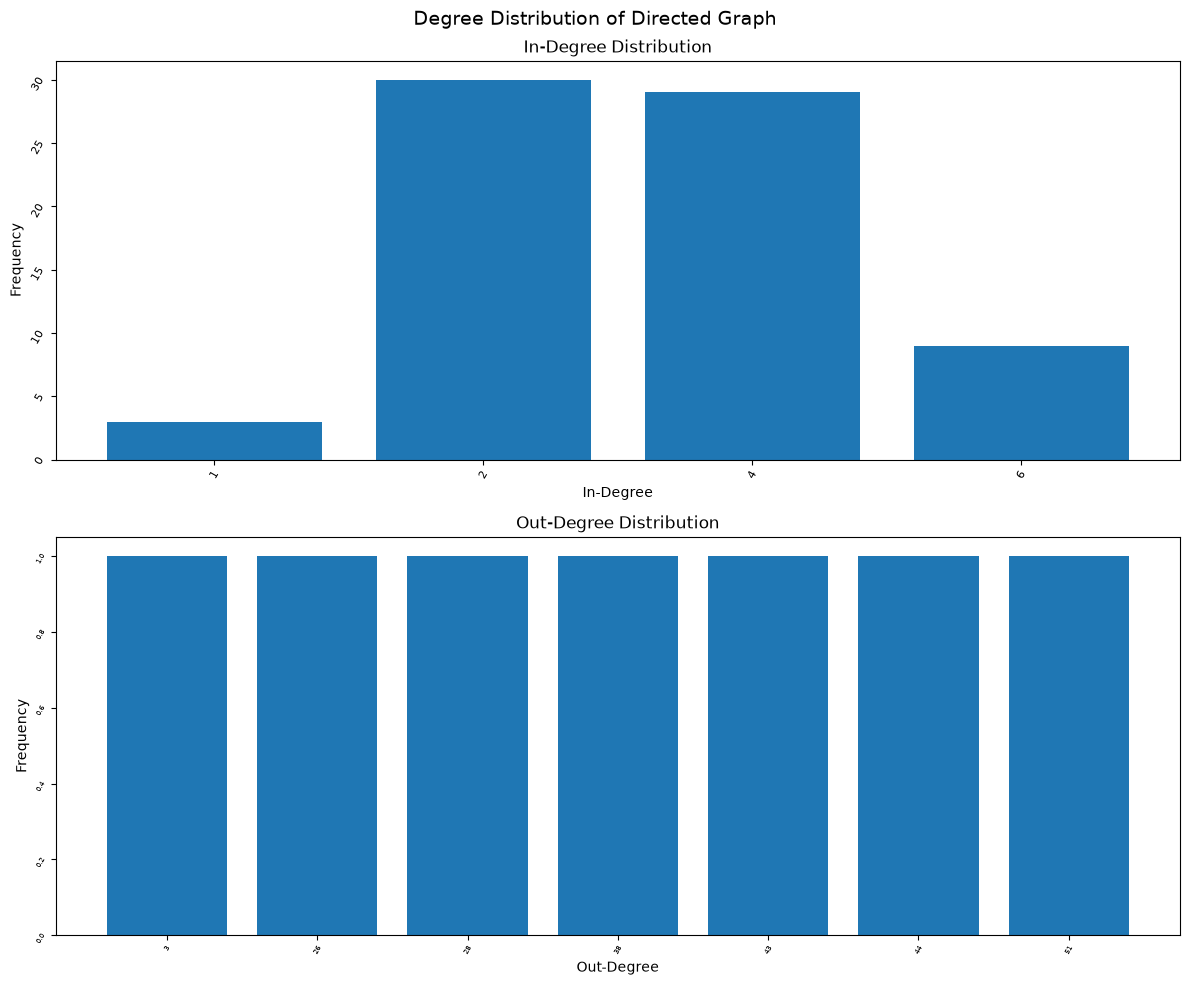

sub Graph of Event.CertificateIssued
224 edges ( 1.38 %)


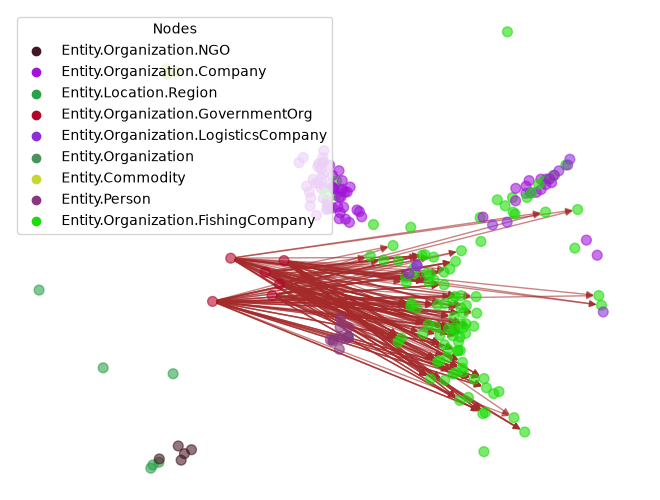

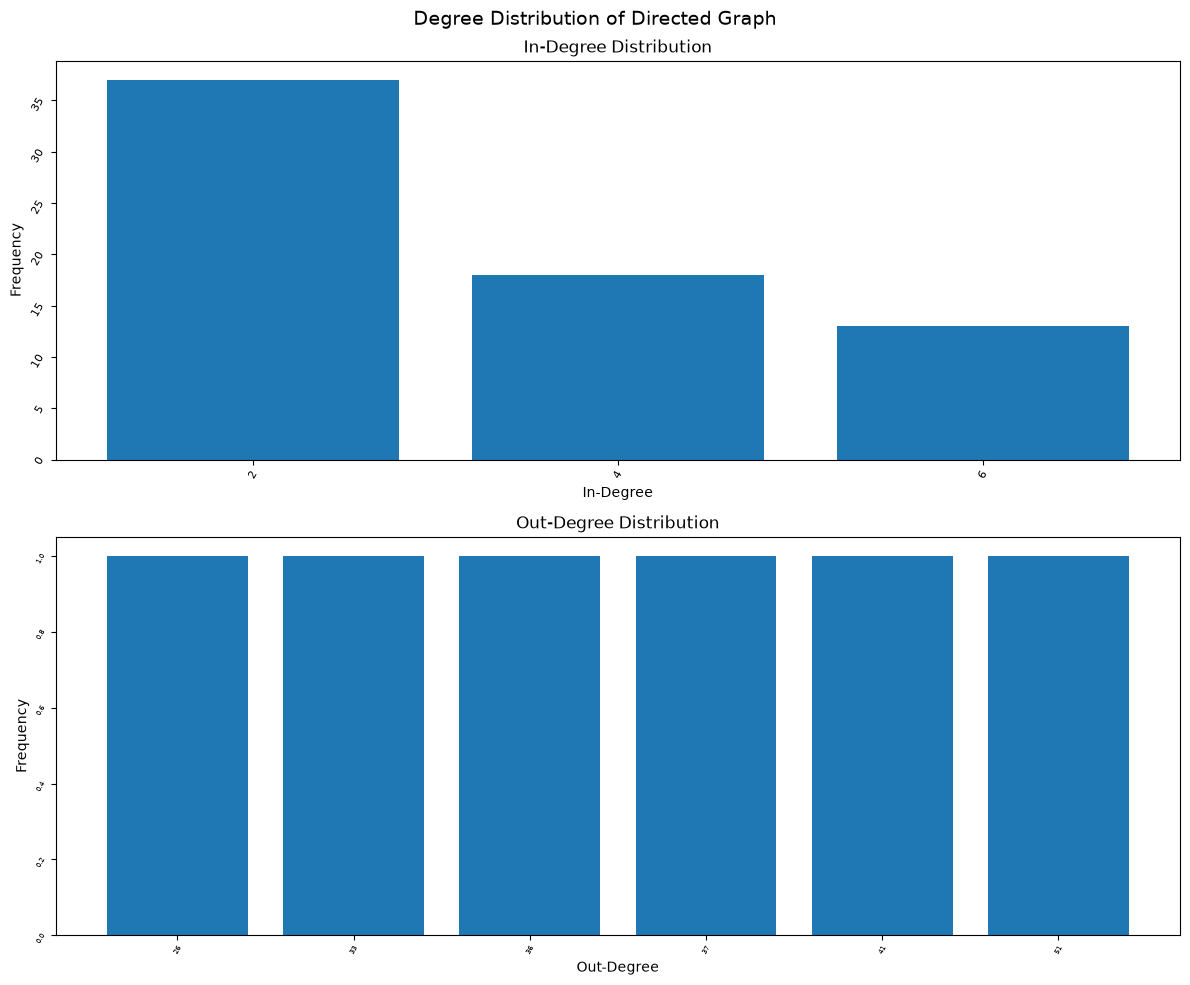

sub Graph of Event.Criticize
401 edges ( 2.47 %)


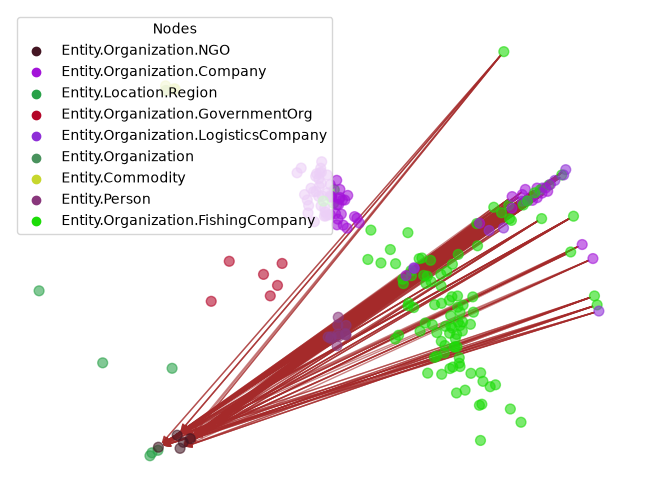

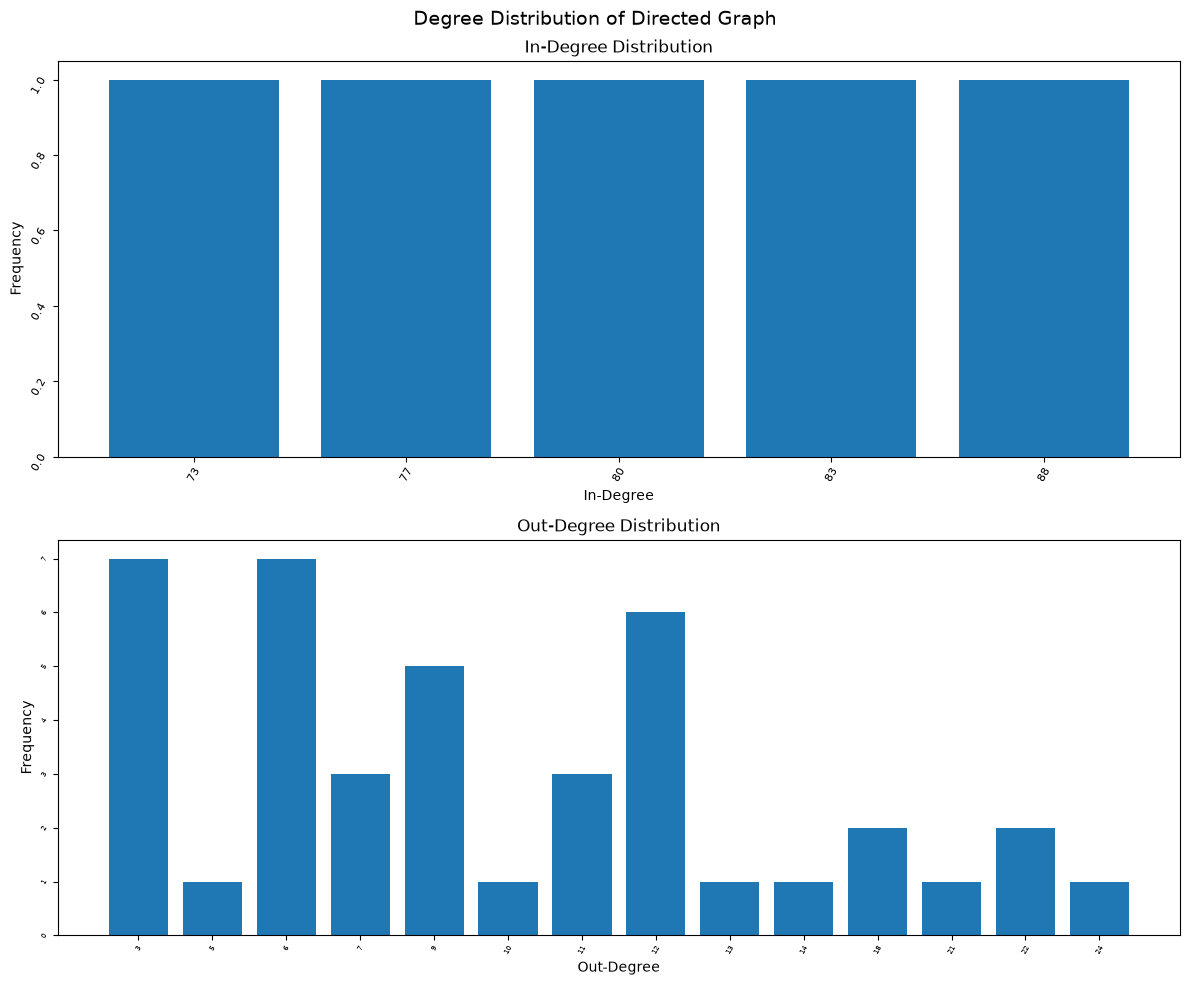

sub Graph of Event.Owns.PartiallyOwns
132 edges ( 0.81 %)


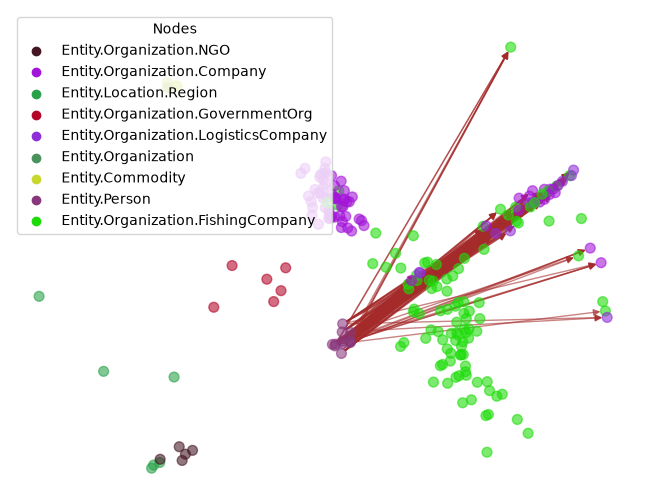

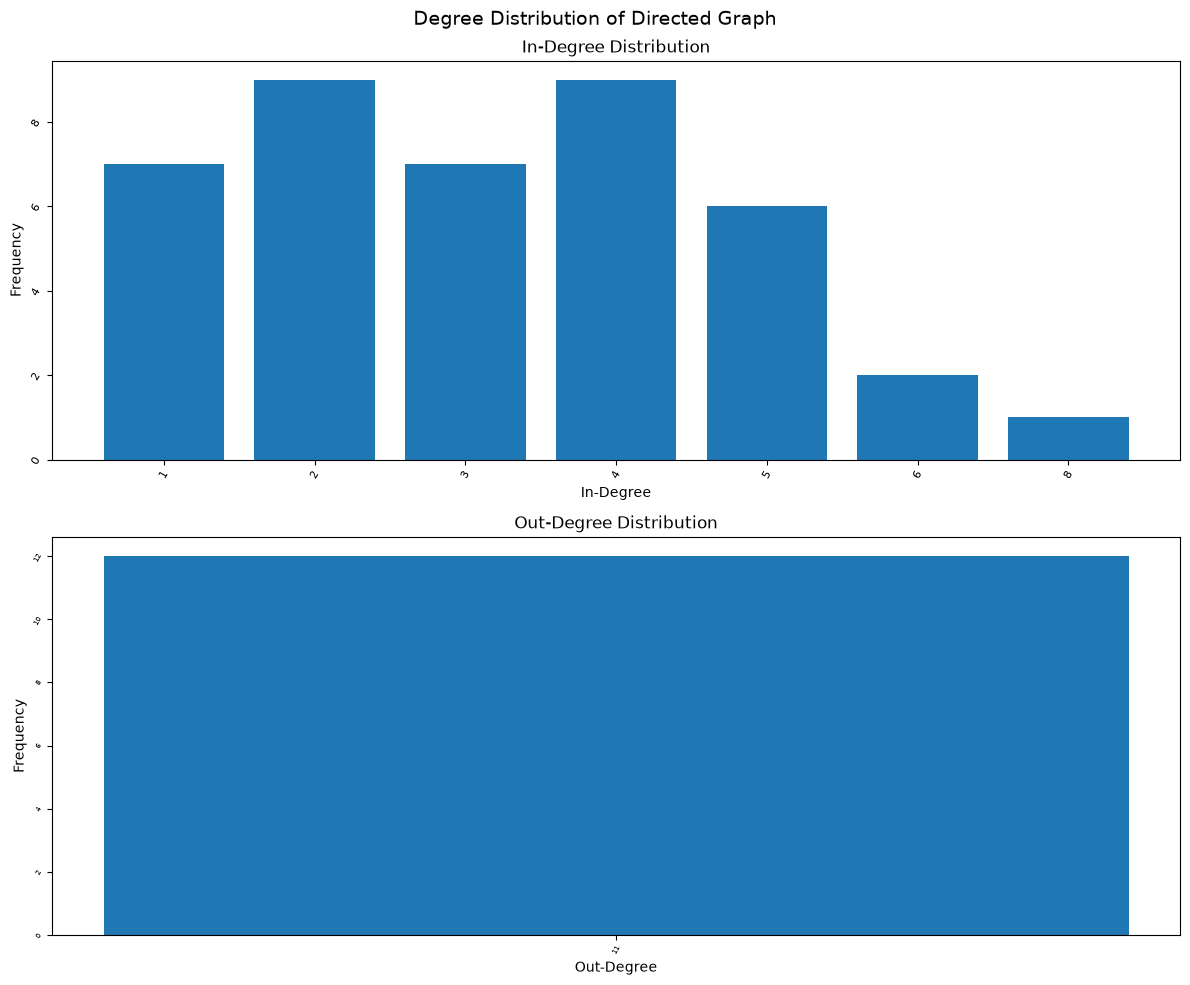

sub Graph of Event.Communication.Conference
797 edges ( 4.91 %)


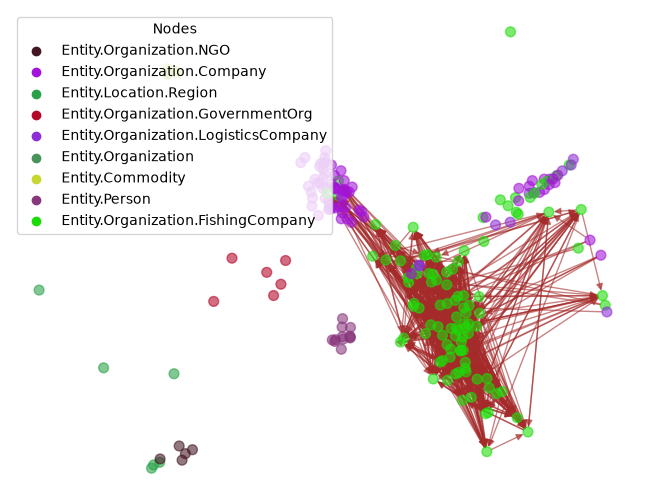

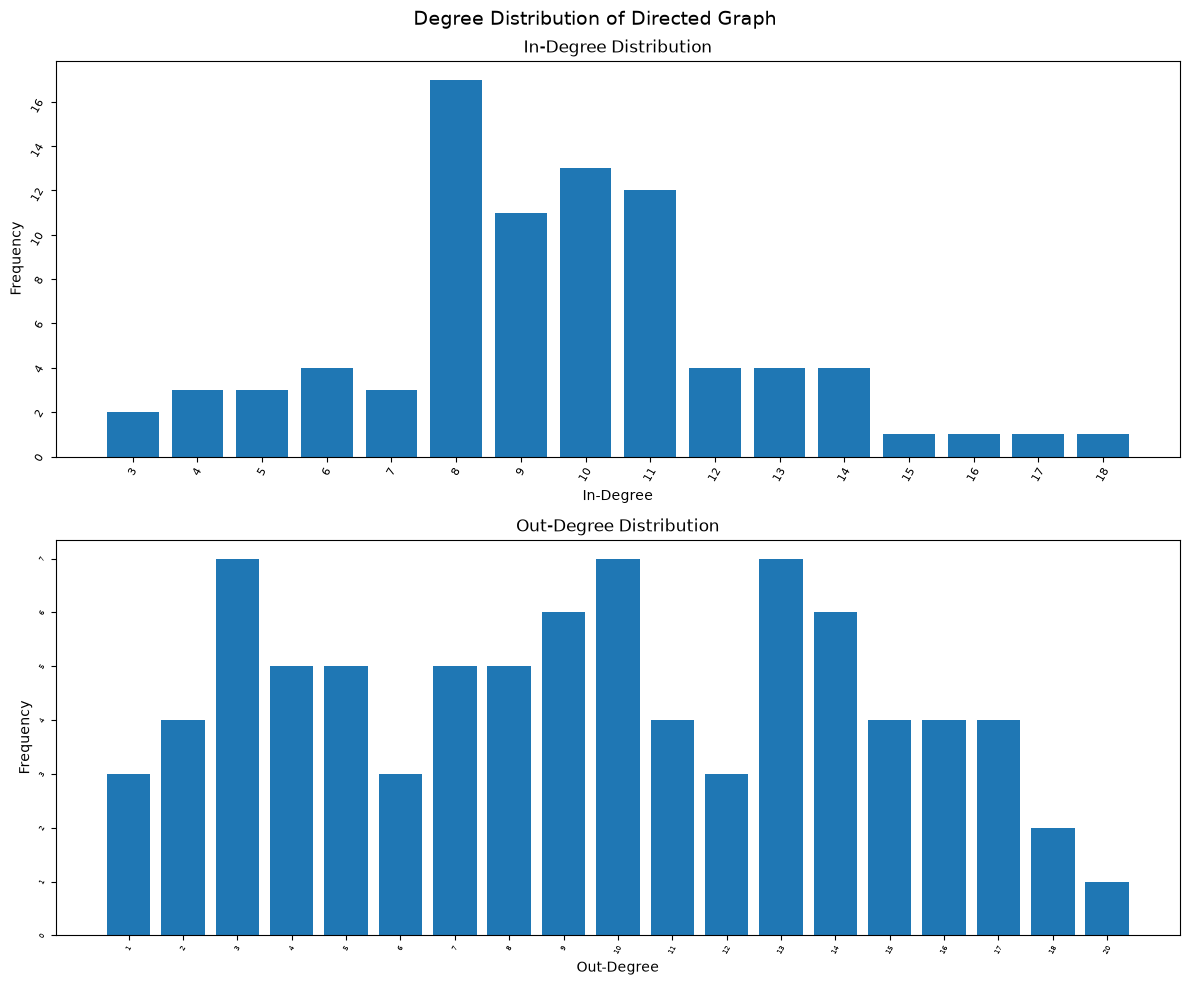

sub Graph of Event.Invest
4374 edges ( 26.95 %)


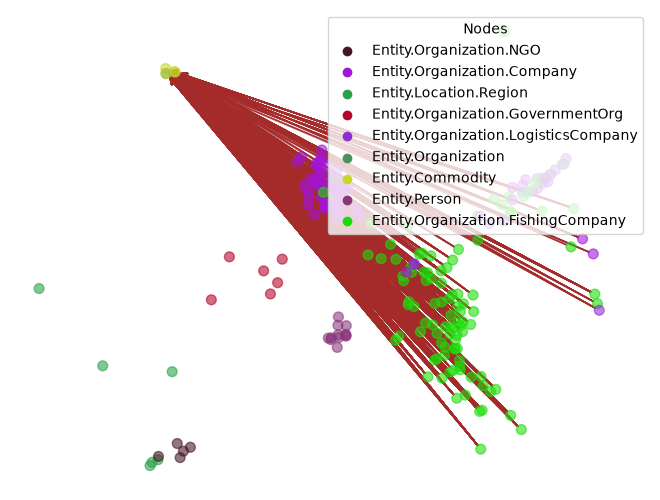

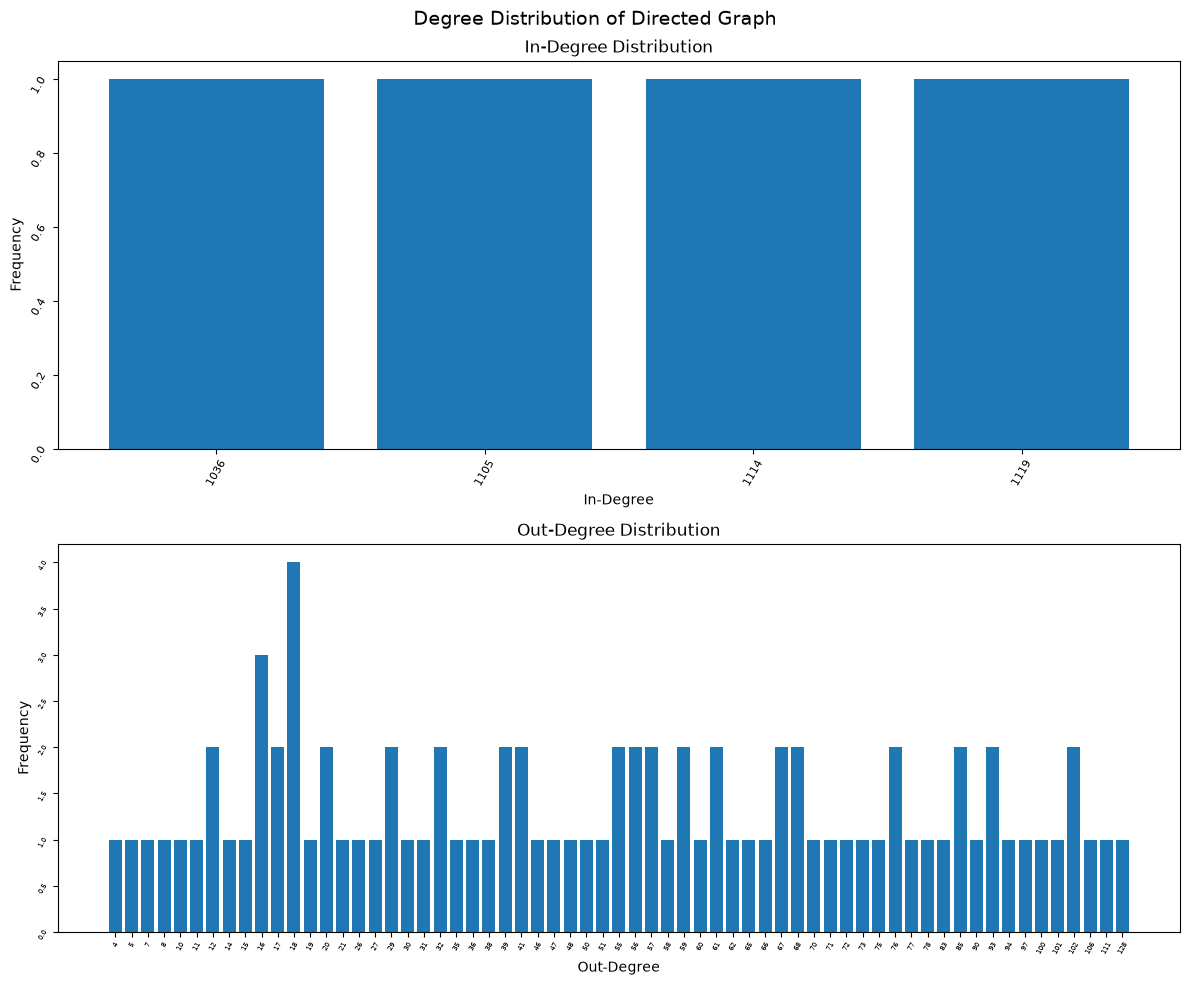

sub Graph of Event.CertificateIssued.Summons
1071 edges ( 6.6 %)


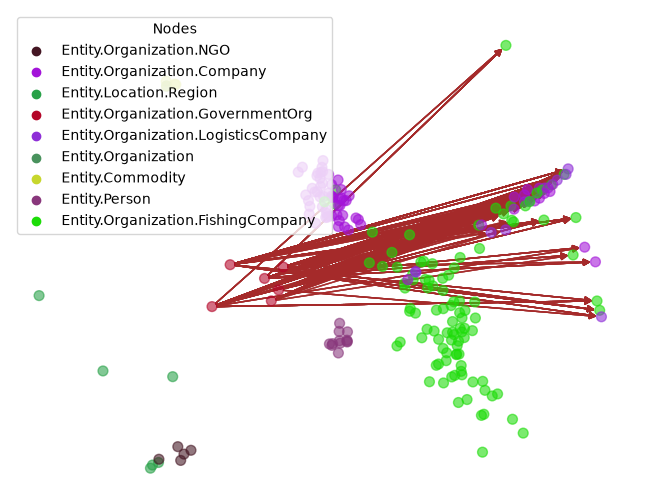

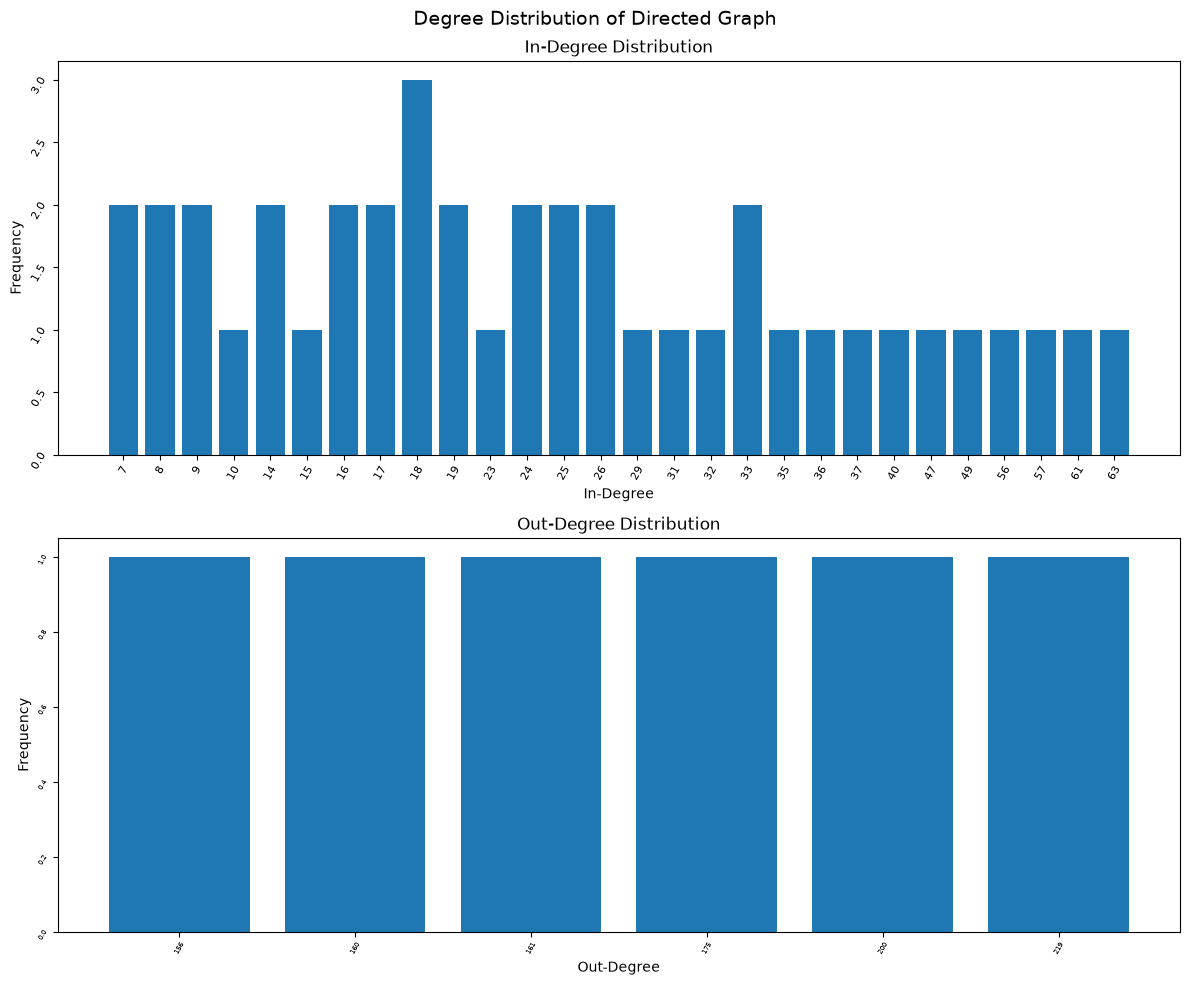

In [13]:
for i, edge_type in enumerate(edges_types):
    sub_graphs[i] = separate_by_edge_type(H, edge_type)
    print('sub Graph of', edges_types[i])
    print(len(sub_graphs[i].edges()), 'edges (',round(len(sub_graphs[i].edges())/len(H.edges()) *100,2),'%)')
    nx.draw(sub_graphs[i],pos=eigen_position,node_size=50,alpha=0.58,edge_color='brown',node_color=color_node)
    plt.legend(handles, list(types_nodes.keys()), title='Nodes')
    plt.show()
    plot_degrees_hist(sub_graphs[i],zero=False)